In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/3d-mri-scans-for-alzheimer-disease/ecc_9_20_2025.csv
/kaggle/input/3d-mri-scans-for-alzheimer-disease/bbc_9_18_2025.csv
/kaggle/input/3d-mri-scans-for-alzheimer-disease/abb_9_13_2025.csv
/kaggle/input/3d-mri-scans-for-alzheimer-disease/abb/ADNI/094_S_1090/MPR__GradWarp__B1_Correction/2006-12-04_09_55_17.0/I63177/ADNI_094_S_1090_MR_MPR__GradWarp__B1_Correction_Br_20070731120149301_S23375_I63177.nii
/kaggle/input/3d-mri-scans-for-alzheimer-disease/abb/ADNI/094_S_1090/MPR-R__GradWarp__B1_Correction__N3/2006-12-04_10_03_32.0/I63180/ADNI_094_S_1090_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070731120539317_S23376_I63180.nii
/kaggle/input/3d-mri-scans-for-alzheimer-disease/abb/ADNI/094_S_1090/MPR-R__GradWarp__B1_Correction/2006-12-04_10_03_32.0/I63181/ADNI_094_S_1090_MR_MPR-R__GradWarp__B1_Correction_Br_20070731120656739_S23376_I63181.nii
/kaggle/input/3d-mri-scans-for-alzheimer-disease/abb/ADNI/094_S_1090/MPR__GradWarp__B1_Correction__N3/2006-12-04_09_55_17.0/I63175/ADNI_094_S

In [2]:
import nibabel as nib
import numpy as np
import cv2
import os
from pathlib import Path
from tqdm.auto import tqdm

# --- Cấu hình đường dẫn (Kaggle) ---
base_input = '/kaggle/input/3d-mri-scans-for-alzheimer-disease'
data_folders = ['abb', 'bbc', 'ecc']
output_base = './all_mri_2d_vit'

# --- Tham số lọc ảnh ---
brightness_threshold = 10
slice_ratio_start = 0.3
slice_ratio_end = 0.7
axial_step = 4
sagittal_step = 7
coronal_step = 7
central_window = 20
var_threshold = 50

def is_slice_valid(slice_2d, brightness_thresh=brightness_threshold):
    # Kiểm tra xem slice có quá tối hoặc trống không
    ratio = np.sum(slice_2d > brightness_thresh) / slice_2d.size
    return ratio > 0.05

def normalize_and_save(slice_2d, save_path):
    # Chuẩn hóa
    slice_2d = slice_2d - np.min(slice_2d)
    if np.max(slice_2d) != 0:
        slice_2d = slice_2d / np.max(slice_2d) * 255
    img_uint8 = slice_2d.astype(np.uint8)
    
    # Kiểm tra độ chi tiết (variance)
    if np.var(img_uint8) < var_threshold:
        return False
        
    # Tăng cường độ tương phản (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_uint8 = clahe.apply(img_uint8)
    
    # Resize chuẩn cho ViT (224x224)
    img_uint8 = cv2.resize(img_uint8, (224, 224))
    
    cv2.imwrite(save_path, img_uint8)
    return True

def process_data():
    total_jpg_created = 0
    
    for label in data_folders:
        label_dir = os.path.join(output_base, label)
        os.makedirs(label_dir, exist_ok=True)
        
        full_path = os.path.join(base_input, label)
        nii_files = list(Path(full_path).rglob('*.nii'))
        
        print(f"\n--- Đang xử lý nhãn: {label} ({len(nii_files)} files) ---")
        
        for nii_path in tqdm(nii_files):
            try:
                img_obj = nib.load(str(nii_path))
                data = img_obj.get_fdata()
                file_stem = nii_path.stem
                
                # 1. Trích xuất Axial
                z_start = int(data.shape[2] * slice_ratio_start)
                z_end = int(data.shape[2] * slice_ratio_end)
                for i in range(z_start, z_end, axial_step):
                    slice_2d = np.rot90(data[:, :, i]) # Xoay cho đúng chiều
                    if is_slice_valid(slice_2d):
                        fname = f"{file_stem}_ax_{i}.jpg"
                        if normalize_and_save(slice_2d, os.path.join(label_dir, fname)):
                            total_jpg_created += 1

                # 2. Trích xuất Sagittal (Mặt cắt dọc bên)
                center_x = data.shape[0] // 2
                for i in range(center_x - central_window, center_x + central_window, sagittal_step):
                    slice_2d = np.rot90(data[i, :, :])
                    if is_slice_valid(slice_2d):
                        fname = f"{file_stem}_sag_{i}.jpg"
                        if normalize_and_save(slice_2d, os.path.join(label_dir, fname)):
                            total_jpg_created += 1

                # 3. Trích xuất Coronal (Mặt cắt đứng ngang)
                center_y = data.shape[1] // 2
                for i in range(center_y - central_window, center_y + central_window, coronal_step):
                    slice_2d = np.rot90(data[:, i, :])
                    if is_slice_valid(slice_2d):
                        fname = f"{file_stem}_cor_{i}.jpg"
                        if normalize_and_save(slice_2d, os.path.join(label_dir, fname)):
                            total_jpg_created += 1
                            
            except Exception as e:
                print(f"Lỗi tại {nii_path.name}: {e}")

    print(f"\n✅ HOÀN THÀNH!")
    print(f"Tổng số ảnh 2D đã tạo: {total_jpg_created}")
    print(f"Dữ liệu lưu tại: {output_base}")

# Chạy hàm
process_data()


--- Đang xử lý nhãn: abb (500 files) ---


  0%|          | 0/500 [00:00<?, ?it/s]


--- Đang xử lý nhãn: bbc (500 files) ---


  0%|          | 0/500 [00:00<?, ?it/s]


--- Đang xử lý nhãn: ecc (500 files) ---


  0%|          | 0/500 [00:00<?, ?it/s]


✅ HOÀN THÀNH!
Tổng số ảnh 2D đã tạo: 42892
Dữ liệu lưu tại: ./all_mri_2d_vit


In [3]:
!ls ./all_mri_2d_vit/abb | wc -l
!ls ./all_mri_2d_vit/bbc | wc -l
!ls ./all_mri_2d_vit/ecc | wc -l

14301
14303
14288


**DeiT**

In [4]:
import os
import glob
import time
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from PIL import Image
import timm
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.decomposition import PCA # Để phân tích PCA
import cv2 # Để tạo Grad-CAM

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [5]:
# =============================
# 1. CẤU HÌNH HỆ THỐNG
# =============================
DATA_DIR = "/kaggle/working/all_mri_2d_vit" # Đã sửa đường dẫn nếu bạn chạy trên Kaggle
VALID_CLASSES = ["abb", "bbc", "ecc"] # Tên các lớp (ví dụ: Normal, Mild AD, Severe AD)
CLASS_LABELS = {i: cls_name for i, cls_name in enumerate(VALID_CLASSES)} # Map index to class name
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
NUM_EPOCHS = 30 # Tăng số epoch để đảm bảo hội tụ hoàn toàn
LR = 3e-4 # Tăng LR một chút với OneCycleLR

In [6]:
# =============================
# 2. XỬ LÝ DỮ LIỆU VÀ DATALOADER
# =============================
def get_subject_split(root_dir, classes, test_size=0.2):
    train_samples, test_samples = [], []
    for cls_idx, cls_name in enumerate(classes):
        cls_dir = os.path.join(root_dir, cls_name)
        all_files = glob.glob(os.path.join(cls_dir, "*.jpg"))
        if not all_files: continue

        subjects = {}
        for f in all_files:
            # Giả định tên file có dạng {subject_id}_s{slice_idx}.jpg
            # Ví dụ: sub-01_s123.jpg -> subject_id = sub-01
            subject_id = os.path.basename(f).rsplit('_s', 1)[0]
            subjects.setdefault(subject_id, []).append(f)
        
        sub_ids = list(subjects.keys())
        tr_ids, te_ids = train_test_split(sub_ids, test_size=test_size, random_state=42, stratify=[cls_name]*len(sub_ids)) # Thêm stratify
        
        for s_id in tr_ids:
            for f in subjects[s_id]: train_samples.append((f, cls_idx))
        for s_id in te_ids:
            for f in subjects[s_id]: test_samples.append((f, cls_idx))
    
    print(f"Tổng số mẫu huấn luyện: {len(train_samples)}")
    print(f"Tổng số mẫu kiểm tra: {len(test_samples)}")
    return train_samples, test_samples

class MRIDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label, path # Trả về cả đường dẫn để dùng cho TTA và Grad-CAM

# Augmentation chuyên dụng và mạnh mẽ cho DeiT & MRI
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandAugment(num_ops=2, magnitude=9), # RandAugment là SOTA cho data augmentation
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Chia tập dữ liệu
train_list, test_list = get_subject_split(DATA_DIR, VALID_CLASSES)
train_dataset = MRIDataset(train_list, train_transform)
test_dataset = MRIDataset(test_list, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2, pin_memory=True)

print(f"✅ Đã cấu hình DataLoader với {os.cpu_count() // 2} num_workers.")
print(f"📊 Khoa học: Chia theo Bệnh nhân (Subject-level Split)")

Tổng số mẫu huấn luyện: 34297
Tổng số mẫu kiểm tra: 8595
✅ Đã cấu hình DataLoader với 2 num_workers.
📊 Khoa học: Chia theo Bệnh nhân (Subject-level Split)


In [7]:
# =============================
# 3. KHỞI TẠO DeiT & OPTIMIZER (TỐI ƯU SOTA)
# =============================
# Sử dụng DeiT base model với pretrained weights từ ImageNet
# drop_path_rate: Stochastic Depth - regularization mạnh mẽ cho ViT
# attn_drop_rate: Dropout trong cơ chế attention
model = timm.create_model(
    'deit_base_patch16_224',
    pretrained=True,
    num_classes=len(VALID_CLASSES),
    drop_path_rate=0.2, # Tăng để chống overfitting trên các features cứng nhắc
    attn_drop_rate=0.1
)
model.to(DEVICE)

# Label Smoothing CrossEntropyLoss: Giúp mô hình không quá "tự tin" vào dự đoán
# Cải thiện khả năng tổng quát hóa và xử lý các mẫu khó phân biệt
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer AdamW: Tối ưu cho Transformer, hiệu quả hơn Adam
# Weight Decay: Regularization để ngăn chặn các trọng số quá lớn
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

# OneCycleLR Scheduler: Lịch trình học tập SOTA, tăng tốc độ hội tụ và độ chính xác
# max_lr: Tốc độ học tối đa
# pct_start: Phần trăm thời gian để tăng LR lên max_lr (warm-up)
# anneal_strategy='cos': Giảm LR theo hàm cosine
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos'
)

# GradScaler cho Mixed Precision Training (FP16):
# Tăng tốc độ huấn luyện gấp ~2 lần và giảm sử dụng VRAM GPU
scaler = GradScaler()

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipykernel_24/3308345801.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [8]:
# =============================
# 4. HÀM HUẤN LUYỆN VÀ ĐÁNH GIÁ (Tối ưu hóa)
# =============================
def train_one_epoch(epoch):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    
    for imgs, labels, _ in pbar: # Bỏ qua path trong lúc train
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        with autocast(): # Mixed Precision Training
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward() # Scale loss để tránh underflow với FP16
        scaler.step(optimizer)        # Cập nhật weights
        scaler.update()               # Cập nhật scaler
        scheduler.step()              # Cập nhật Learning Rate
        
        total_loss += loss.item()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
        pbar.set_postfix(loss=f"{total_loss/len(pbar):.4f}", acc=f"{100.*correct/total:.2f}%", lr=f"{optimizer.param_groups[0]['lr']:.6f}")

    return total_loss/len(pbar), 100.*correct/total

def validate():
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    all_probs = [] # Để tính ROC AUC
    
    with torch.no_grad():
        for imgs, labels, _ in tqdm(test_loader, desc="[Validating]"): # Bỏ qua path
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = F.softmax(outputs, dim=1)
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy()) # Lưu xác suất
            
    return total_loss/len(test_loader), 100.*correct/total, all_labels, all_preds, np.array(all_probs)

In [9]:
# =============================
# 5. THỰC THI HUẤN LUYỆN CHÍNH
# =============================
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

early_stopping = EarlyStopping(patience=5, verbose=True)
best_acc = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print("\n--- BẮT ĐẦU HUẤN LUYỆN ---")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc, y_true, y_pred, y_probs = validate() # Lấy thêm y_probs
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"📊 Kết quả Epoch {epoch+1}: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'deit_alzheimer_best.pth')
        print(f"⭐ Đã lưu Model tốt nhất với Val Acc: {best_acc:.2f}%")

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("🛑 Early stopping: Mô hình đã ngừng cải thiện. Kết thúc huấn luyện sớm.")
        break

print("\n--- HUẤN LUYỆN HOÀN TẤT ---")


--- BẮT ĐẦU HUẤN LUYỆN ---


Epoch 1/30 [Train]:   0%|          | 0/536 [00:00<?, ?it/s]

/tmp/ipykernel_24/3809647052.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Mixed Precision Training


[Validating]:   0%|          | 0/135 [00:00<?, ?it/s]

📊 Kết quả Epoch 1: Train Acc: 41.82% | Val Acc: 50.70% | Val Loss: 1.0066
⭐ Đã lưu Model tốt nhất với Val Acc: 50.70%


...

[Validating]:   0%|          | 0/135 [00:00<?, ?it/s]

📊 Kết quả Epoch 29: Train Acc: 94.80% | Val Acc: 93.18% | Val Loss: 0.4282
EarlyStopping counter: 2 out of 5


Epoch 30/30 [Train]:   0%|          | 0/536 [00:00<?, ?it/s]

[Validating]:   0%|          | 0/135 [00:00<?, ?it/s]

📊 Kết quả Epoch 30: Train Acc: 94.63% | Val Acc: 93.19% | Val Loss: 0.4276
EarlyStopping counter: 3 out of 5

--- HUẤN LUYỆN HOÀN TẤT ---



--- BÁO CÁO ĐÁNH GIÁ CUỐI CÙNG ---


[Validating]:   0%|          | 0/135 [00:00<?, ?it/s]


🔥 Độ chính xác cuối cùng trên tập kiểm tra: 93.21%

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

         abb       0.95      0.96      0.96      2856
         bbc       0.91      0.90      0.91      2861
         ecc       0.93      0.94      0.93      2878

    accuracy                           0.93      8595
   macro avg       0.93      0.93      0.93      8595
weighted avg       0.93      0.93      0.93      8595



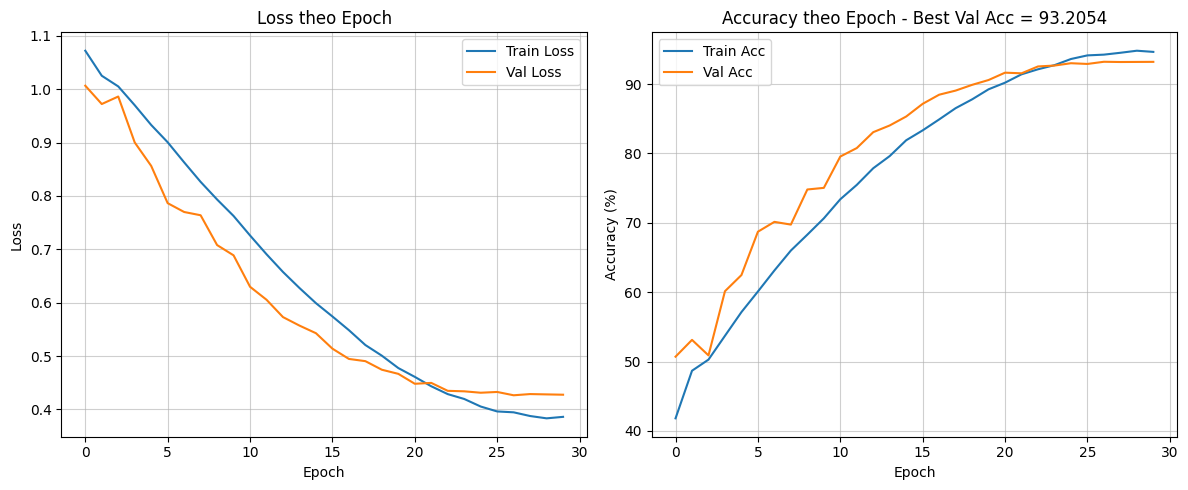

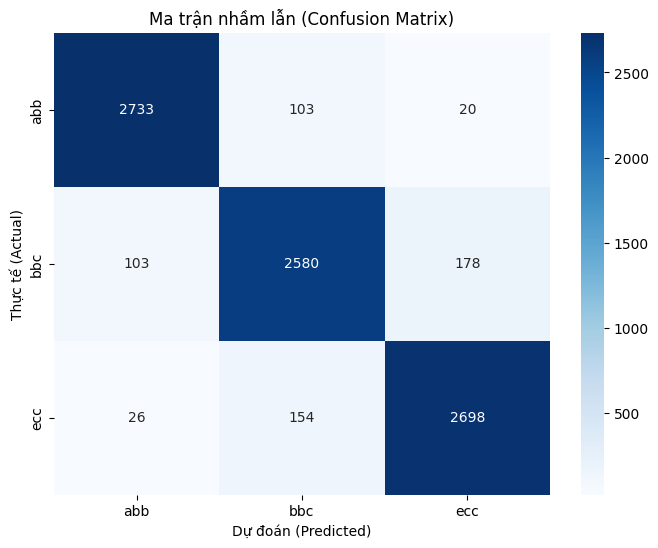

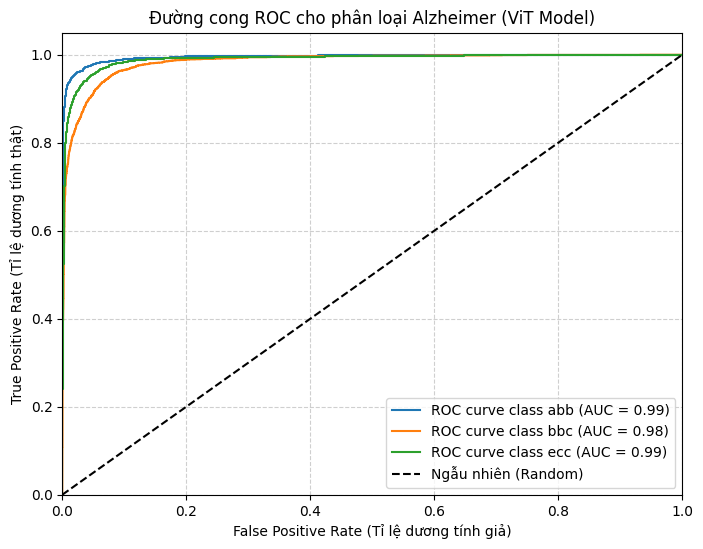

In [10]:
# =============================
# 6. ĐÁNH GIÁ CUỐI CÙNG VÀ VISUALIZE
# =============================
print("\n--- BÁO CÁO ĐÁNH GIÁ CUỐI CÙNG ---")
# Tải lại mô hình tốt nhất để đánh giá
model.load_state_dict(torch.load('deit_alzheimer_best.pth'))
_, final_acc, y_true, y_pred, y_probs = validate() # Chạy validate lần cuối với model tốt nhất

print(f"\n🔥 Độ chính xác cuối cùng trên tập kiểm tra: {final_acc:.2f}%")
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
print(classification_report(y_true, y_pred, target_names=VALID_CLASSES))

# Biểu đồ Loss và Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss theo Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title(f'Accuracy theo Epoch - Best Val Acc = {best_acc:.4f}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()
plt.show()

# Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=VALID_CLASSES, yticklabels=VALID_CLASSES)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

# Đường cong ROC và AUC
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(VALID_CLASSES):
    fpr, tpr, _ = roc_curve(np.array(y_true) == i, y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve class {class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (Random)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Tỉ lệ dương tính giả)')
plt.ylabel('True Positive Rate (Tỉ lệ dương tính thật)')
plt.title('Đường cong ROC cho phân loại Alzheimer (ViT Model)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Trích xuất đặc trưng:   0%|          | 0/135 [00:00<?, ?it/s]

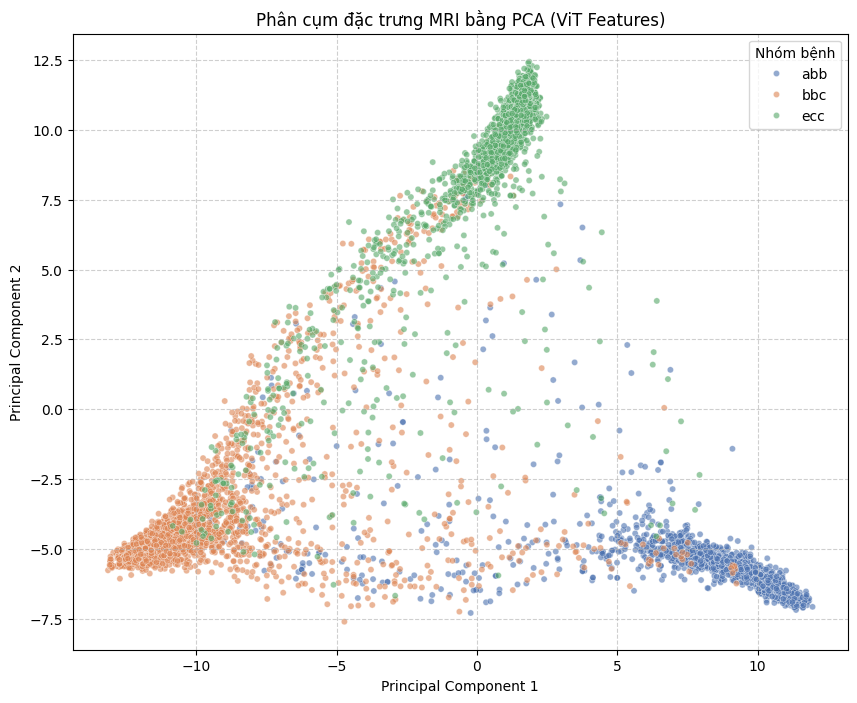

In [11]:
# =============================
# 7. PHÂN TÍCH ĐẶC TRƯNG PCA (Feature Visualization)
# =============================
def get_features(model, dataloader):
    model.eval()
    features_list = []
    labels_list = []
    with torch.no_grad():
        for imgs, labels, _ in tqdm(dataloader, desc="Trích xuất đặc trưng"):
            imgs = imgs.to(DEVICE)
            # Lấy output từ lớp tiền cuối cùng (trước lớp phân loại)
            # Đối với DeiT, thường là output của global average pooling sau Transformer Encoder
            # Ta sẽ lấy output của global average pooling (cls_token) hoặc cuối cùng trước head
            # Kiểm tra kiến trúc của DeiT bằng cách print(model) để tìm lớp phù hợp
            # Ví dụ: model.head là lớp phân loại, ta cần feature trước đó.
            # Với timm DeiT, ta có thể lấy features từ 'forward_features'
            features = model.forward_features(imgs)
            # Nếu features có nhiều token (patch tokens), ta có thể lấy cls_token hoặc avg pool
            # cls_token là token đầu tiên (batch, 1, hidden_dim)
            if features.dim() == 3: # Nếu có dạng (batch, num_tokens, hidden_dim)
                features = features[:, 0, :] # Lấy CLS token
            
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
    return np.concatenate(features_list), np.concatenate(labels_list)

# Lấy đặc trưng từ tập test
test_features, test_labels = get_features(model, test_loader)

# Thực hiện PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(test_features)

# Vẽ biểu đồ PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=principal_components[:, 0], y=principal_components[:, 1],
    hue=[VALID_CLASSES[l] for l in test_labels],
    palette='deep', alpha=0.6, s=20
)
plt.title('Phân cụm đặc trưng MRI bằng PCA (ViT Features)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Nhóm bệnh')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [12]:
!pip install ttach grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=4c221bc8a30f40b5d26914d5d6098d90af0b2e8534a8e9543dc2a4c20e7eae3b
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


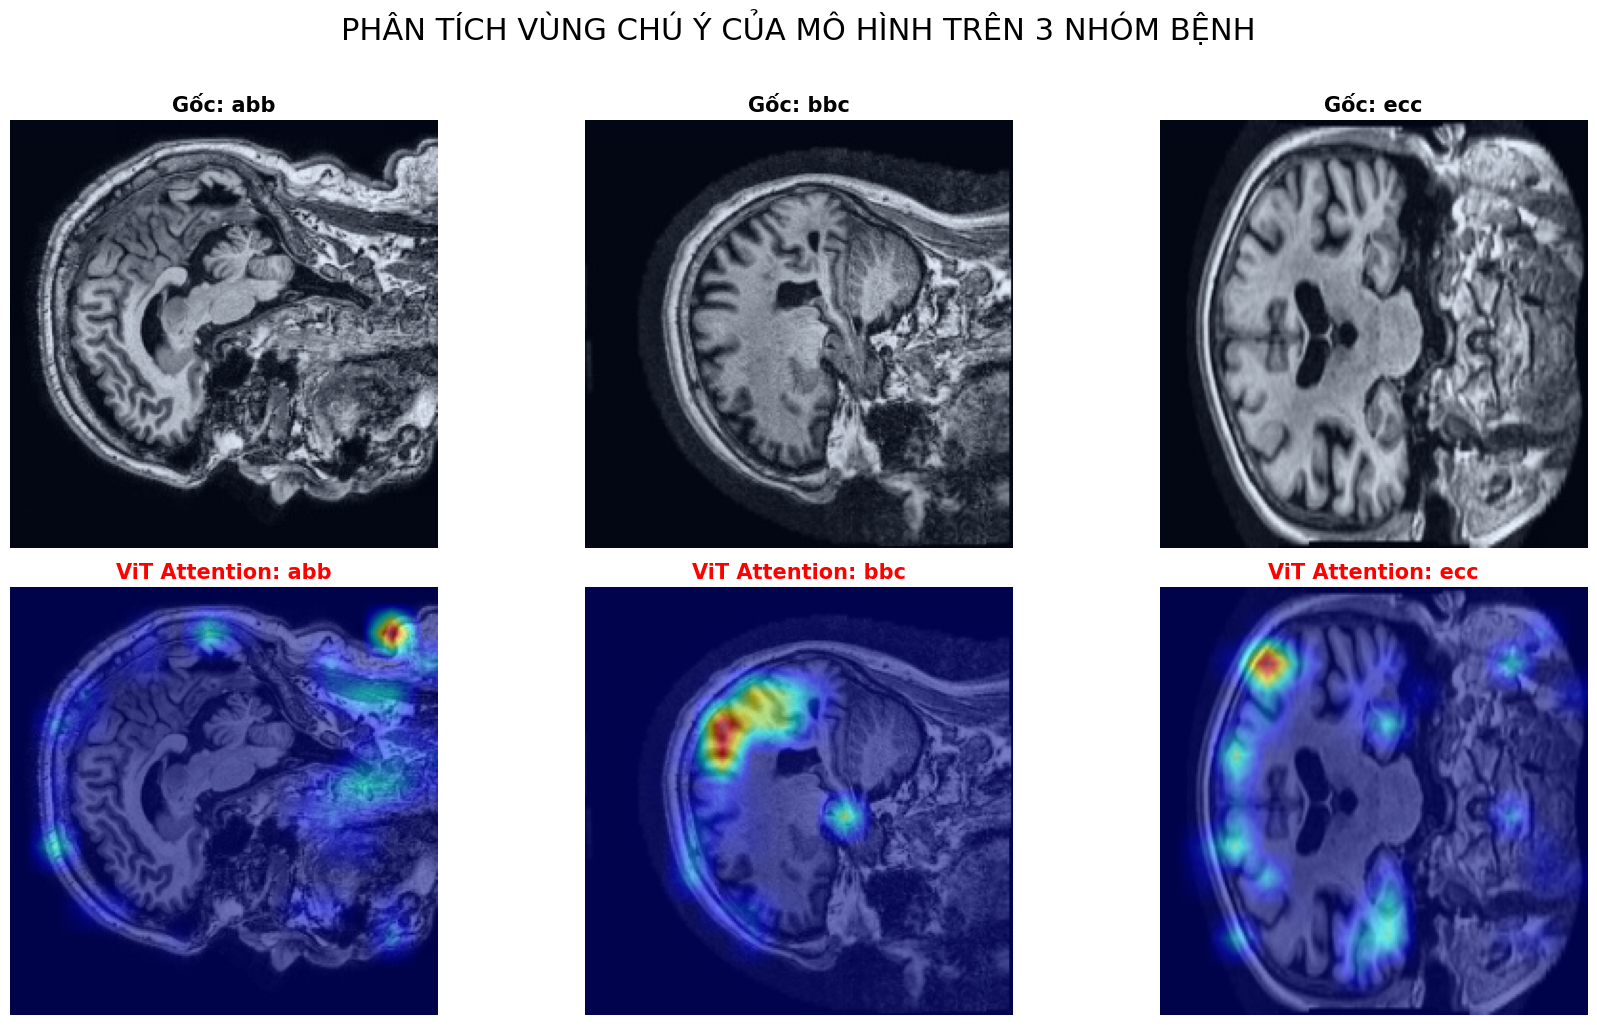

In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- BƯỚC 1: HÀM RESHAPE (Bắt buộc cho Vision Transformer) ---
def reshape_transform(tensor, height=14, width=14):
    # tensor: [batch, 197, 768] (1 CLS token + 196 patch tokens)
    # Bỏ qua CLS token (index 0), lấy 196 tokens còn lại
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    # Chuyển về dạng [Batch, Channels, Height, Width]
    result = result.permute(0, 3, 1, 2)
    return result

# --- BƯỚC 2: CẤU HÌNH GRAD-CAM ---
model.eval()
target_layers = [model.blocks[-1].norm1] # Lớp chuẩn cho DeiT
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

# --- BƯỚC 3: LẤY ẢNH ĐẠI DIỆN CHO 3 LỚP ---
class_names = VALID_CLASSES # ["abb", "bbc", "ecc"]
selected_samples = {}

# Duyệt loader để tìm mỗi lớp 1 ảnh mẫu
with torch.no_grad():
    for imgs, labels, _ in test_loader:
        for i in range(len(labels)):
            c_idx = labels[i].item()
            if c_idx not in selected_samples:
                selected_samples[c_idx] = imgs[i:i+1] # Lưu ảnh dưới dạng batch 1
            if len(selected_samples) == len(class_names):
                break
        if len(selected_samples) == len(class_names):
            break

# --- BƯỚC 4: VẼ BIỂU ĐỒ ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i in range(len(class_names)):
    input_tensor = selected_samples[i].to(DEVICE)
    
    # Chạy Grad-CAM cho lớp i
    targets = [ClassifierOutputTarget(i)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Chuẩn hóa ảnh gốc để hiển thị
    img_raw = input_tensor[0].cpu().permute(1, 2, 0).numpy()
    # De-normalize cơ bản để ảnh MRI hiện rõ (không bị ám màu xanh/đỏ)
    img_norm = (img_raw - img_raw.min()) / (img_raw.max() - img_raw.min() + 1e-8)
    
    # Trộn heatmap
    visualization = show_cam_on_image(img_norm, grayscale_cam, use_rgb=True)
    
    # Hiển thị
    axes[0, i].imshow(img_norm)
    axes[0, i].set_title(f"Gốc: {class_names[i]}", fontsize=15, fontweight='bold')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(visualization)
    axes[1, i].set_title(f"ViT Attention: {class_names[i]}", fontsize=15, color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle("PHÂN TÍCH VÙNG CHÚ Ý CỦA MÔ HÌNH TRÊN 3 NHÓM BỆNH", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()